# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ubaidrees/flyrank-ml-tasks/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes
The queue combines the honest model (client-grouped, AUC 0.604) with human-readable reason codes drawn from the same features found meaningful across Weeks 5-6: content_age_days, avg_position, ctr, days_since_last_update. Each row gets exactly one primary reason code, an action label, and a score — deliberately reusing the ML-07 baseline rule as a secondary, transparent cross-check rather than discarding it.

A systematic check found 23 clients (55.8% of all rows) show a bulk-update artifact — over half their pages share one identical days_since_last_update value, almost certainly a migration or mass-republish date rather than genuine editorial activity. This likely explains the confusing staleness reversal found in ML-07. Rows are still scored and ranked, but flagged with bulk_event_flag so reviewers know days_since_last_update-based reasoning is unreliable for them specifically.

Bulk-event rows show a modestly higher decline rate (56.3%) than non-bulk-event rows (51.6%) — a real but moderate 4.7-point gap. This doesn't prove the artifact causes apparent decline, but it means any client-level decline comparison should control for bulk-event status before drawing conclusions.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("https://raw.githubusercontent.com/Ubaidrees/flyrank-ml-tasks/main/data/raw/content_refresh_anonymized.csv")
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)
df = df[(df['impressions_90d'] > 0) & (df['content_age_days'] >= 90)].copy()
df = df.drop_duplicates(subset='content_id')

feature_cols = [c for c in [
    'impressions_90d', 'clicks_90d', 'sessions_90d', 'ai_sessions_90d',
    'content_age_days', 'days_since_last_update',
    'ctr', 'avg_position', 'engagement_rate', 'scroll_rate',
    'word_count', 'ai_traffic_pct'
] if c in df.columns]

X = df[feature_cols].fillna(0)
y = df['is_declining_label']
groups = df['client_id']

# Honest, client-grouped split — same design validated in ML-08/ML-09
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Score EVERY row (the queue is for content ops, not just the held-out test slice)
df['risk_score'] = model.predict_proba(X)[:, 1]

# ---- Reason codes: one primary reason per row, in priority order ----
def assign_reason(row):
    if row['days_since_last_update'] >= 180 and row['impressions_90d'] >= 500 and 0 < row['avg_position'] <= 20 and row['ctr'] < 0.5:
        return 'stale_page_ctr_gap'  # matches ML-07's audited baseline rule
    elif row['impressions_90d'] >= 5000 and row['risk_score'] >= 0.5:
        return 'high_volume_risk'    # biggest potential upside if wrong
    elif row['days_since_last_update'] >= 180:
        return 'stale_needs_review'
    elif row['ctr'] < 0.15 and 0 < row['avg_position'] <= 20:
        return 'low_ctr_visible_page'
    else:
        return 'general_monitor'

df['reason_code'] = df.apply(assign_reason, axis=1)

action_map = {
    'stale_page_ctr_gap': 'review_for_refresh',
    'high_volume_risk': 'priority_review',
    'stale_needs_review': 'review_for_refresh',
    'low_ctr_visible_page': 'review_snippet_ctr',
    'general_monitor': 'monitor_only',
}
df['action'] = df['reason_code'].map(action_map)

queue = df.sort_values('risk_score', ascending=False)[
    ['content_id', 'client_id', 'risk_score', 'reason_code', 'action',
     'days_since_last_update', 'impressions_90d', 'avg_position', 'ctr']
]

print(f"Total scored: {len(queue)}")
print(queue['reason_code'].value_counts())
print("\nTop 10:")
print(queue.head(10).to_string(index=False))

Total scored: 30000
reason_code
general_monitor         16973
low_ctr_visible_page     9655
high_volume_risk         3201
stale_needs_review        161
stale_page_ctr_gap         10
Name: count, dtype: int64

Top 10:
          content_id         client_id  risk_score      reason_code          action  days_since_last_update  impressions_90d  avg_position  ctr
content_267d8cf80905 client_7f2253d7e2    0.837400 high_volume_risk priority_review                      20            20947          16.0 0.79
content_1d533efd8c4d client_7f2253d7e2    0.835596 high_volume_risk priority_review                      20            18117          12.7 0.77
content_20e4b9f7f65e client_7f2253d7e2    0.833660 high_volume_risk priority_review                      20            12992          15.2 0.90
content_b61233d4bc91 client_7f2253d7e2    0.833063 high_volume_risk priority_review                      20            14863          18.2 0.89
content_69cfaabeda16 client_7f2253d7e2    0.832364 high_volume_

In [6]:
# Investigate: impossible CTR values
print("Rows with CTR > 1.0 (impossible):", (df['ctr'] > 1.0).sum())
print(df[df['ctr'] > 1.0][['content_id', 'client_id', 'ctr', 'impressions_90d', 'clicks_90d']].head(10))

# Investigate: is client_7f2253d7e2's uniform days_since_last_update a real pattern or a data artifact?
client_check = df[df['client_id'] == 'client_7f2253d7e2']
print(f"\nclient_7f2253d7e2 total rows: {len(client_check)}")
print(f"Rows with days_since_last_update == 20: {(client_check['days_since_last_update'] == 20).sum()}")
print(f"This client's days_since_last_update value counts:")
print(client_check['days_since_last_update'].value_counts().head(10))

Rows with CTR > 1.0 (impossible): 1689
              content_id          client_id    ctr  impressions_90d  \
10  content_d8ee6cc6d642  client_19581e27de   1.55            20919   
12  content_42fb2cad9ecf  client_6208ef0f77   1.76             7228   
15  content_689414059706  client_9f14025af0  23.68               38   
19  content_af865035b328  client_f369cb89fc   2.02               99   
36  content_bce275871a25  client_f369cb89fc   1.35              371   
37  content_724a2783045d  client_4e07408562   1.07              187   
40  content_4df0b7207fe3  client_9f14025af0   1.65             1700   
42  content_3223b1640f5a  client_a88a7902cb   1.27              157   
60  content_b9104a222d01  client_f369cb89fc   4.00               25   
61  content_d99c66ea5462  client_d4735e3a26  11.11                9   

    clicks_90d  
10         324  
12         127  
15           9  
19           2  
36           5  
37           2  
40          28  
42           2  
60           1  
61       

In [7]:
# Fix 1: recompute CTR uniformly from raw clicks/impressions, ignore the inconsistent stored column
df['ctr'] = (df['clicks_90d'] / df['impressions_90d']).clip(upper=1.0)

# Fix 2 (verification, not a fix): don't remove client_7f2253d7e2, but flag it
bulk_event_clients = df.groupby('client_id')['days_since_last_update'].apply(
    lambda x: (x.value_counts(normalize=True).max() > 0.5)  # one value >50% of that client's rows
)
suspect_clients = bulk_event_clients[bulk_event_clients].index.tolist()
print(f"Clients with a likely bulk-update event (>50% identical days_since_last_update): {len(suspect_clients)}")
print(suspect_clients[:10])

df['bulk_event_flag'] = df['client_id'].isin(suspect_clients)
print(f"\nRows affected by a bulk-event client: {df['bulk_event_flag'].sum()} of {len(df)}")

# Rebuild features/label/split/model on the corrected df — same as Cell 2, just re-run in full now
X = df[feature_cols].fillna(0)
y = df['is_declining_label']
groups = df['client_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
df['risk_score'] = model.predict_proba(X)[:, 1]
df['reason_code'] = df.apply(assign_reason, axis=1)
df['action'] = df['reason_code'].map(action_map)

queue = df.sort_values('risk_score', ascending=False)[
    ['content_id', 'client_id', 'risk_score', 'reason_code', 'action', 'bulk_event_flag',
     'days_since_last_update', 'impressions_90d', 'avg_position', 'ctr']
]
print(queue['reason_code'].value_counts())
print("\nTop 10 (corrected):")
print(queue.head(10).to_string(index=False))

Clients with a likely bulk-update event (>50% identical days_since_last_update): 23
['client_02d20bbd7e', 'client_1a6562590e', 'client_25fc0e7096', 'client_2c624232cd', 'client_349c41201b', 'client_3fdba35f04', 'client_4fc82b26ae', 'client_6208ef0f77', 'client_7f2253d7e2', 'client_8b940be7fb']

Rows affected by a bulk-event client: 16740 of 30000
reason_code
low_ctr_visible_page    17851
general_monitor          8783
high_volume_risk         3195
stale_needs_review        161
stale_page_ctr_gap         10
Name: count, dtype: int64

Top 10 (corrected):
          content_id         client_id  risk_score      reason_code          action  bulk_event_flag  days_since_last_update  impressions_90d  avg_position      ctr
content_370de6e8e035 client_7f2253d7e2    0.848578 high_volume_risk priority_review             True                      20           114389          39.7 0.001285
content_b61233d4bc91 client_7f2253d7e2    0.848452 high_volume_risk priority_review             True            

In [8]:
print(f"Bulk-event clients affect {df['bulk_event_flag'].sum()} of {len(df)} rows ({df['bulk_event_flag'].mean()*100:.1f}%)")

# Confirm: does the days_since_last_update feature actually matter less than it should for these rows?
for flag_value in [True, False]:
    subset = df[df['bulk_event_flag'] == flag_value]
    print(f"\nbulk_event_flag={flag_value}: n={len(subset)}, decline rate={subset['is_declining_label'].mean():.3f}")

Bulk-event clients affect 16740 of 30000 rows (55.8%)

bulk_event_flag=True: n=16740, decline rate=0.563

bulk_event_flag=False: n=13260, decline rate=0.516


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Bulk-event contamination: 55.8% of rows come from clients whose days_since_last_update looks artificially uniform — a real, traced data-quality issue, not a hypothetical caveat. For any row with bulk_event_flag=True, treat days_since_last_update as unreliable; the model's risk_score for these rows leans partly on a feature that doesn't mean what it appears to mean.

In [2]:
intended_use = """
INTENDED USE: This queue supports a content team's weekly triage — deciding which
pages to review first for refresh, CTR/snippet fixes, or continued monitoring.
It is decision-support, not an automated action system.

LIMITS (from six weeks of validated findings):
- Honest accuracy is AUC 0.604 (client-grouped validation, ML-08/ML-09) — a real,
  moderate signal, not near-certain prediction. A naive, ungrouped split falsely
  suggested AUC 0.745; that inflated number should never be quoted publicly.
- impressions_90d is partially leaky: removing it alone drops AUC to 0.551 (ML-09),
  meaning part of its predictive value comes from structural overlap with how the
  label itself is calculated, not pure independent signal. Treat rows whose only
  strong signal is impressions_90d with extra skepticism.
- Staleness (days_since_last_update) has a non-linear, partially reversed
  relationship with decline (ML-07): it predicts decline up to ~180 days, then
  reverses for content stale 180+ days — likely because very stale content has
  already bottomed out. The rule and model may both under-flag the most extreme
  staleness cases.
- The baseline rule alone flags very few pages (10 of 30,000, ML-07) — it is a
  useful cross-check, not a sufficient queue on its own.
- Validated on a single historical snapshot of one dataset; not validated across
  seasons, industries, or content types outside this portfolio.
"""
print(intended_use)


INTENDED USE: This queue supports a content team's weekly triage — deciding which
pages to review first for refresh, CTR/snippet fixes, or continued monitoring.
It is decision-support, not an automated action system.

LIMITS (from six weeks of validated findings):
- Honest accuracy is AUC 0.604 (client-grouped validation, ML-08/ML-09) — a real,
  moderate signal, not near-certain prediction. A naive, ungrouped split falsely
  suggested AUC 0.745; that inflated number should never be quoted publicly.
- impressions_90d is partially leaky: removing it alone drops AUC to 0.551 (ML-09),
  meaning part of its predictive value comes from structural overlap with how the
  label itself is calculated, not pure independent signal. Treat rows whose only
  strong signal is impressions_90d with extra skepticism.
- Staleness (days_since_last_update) has a non-linear, partially reversed
  relationship with decline (ML-07): it predicts decline up to ~180 days, then
  reverses for content stale 180+ da

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Do not act on stale_needs_review or stale_page_ctr_gap reason codes for any row with bulk_event_flag=True without first manually confirming the page's real last-edit date — the stored value is very likely a migration artifact, not genuine freshness.

In [3]:
human_review_rules = """
BEFORE ACTING ON ANY ROW, A HUMAN MUST:
1. Confirm the page still exists and matches its current intent/audience.
2. Check whether reason_code is 'high_volume_risk' or 'stale_page_ctr_gap' —
   these carry the most evidence behind them; 'general_monitor' rows need no action.
3. For any row where impressions_90d is the dominant driver, manually verify
   against avg_position and ctr before treating the score as trustworthy
   (see the leakage note in Section 2).

NO-GO — NEVER AUTOMATE THESE:
- Do not auto-publish, auto-delete, or auto-redirect any page based on this score alone.
- Do not use this queue for legal, medical, financial, or other YMYL content without
  senior editorial + subject-matter review, regardless of score.
- Do not treat risk_score as a probability guarantee for any single page — it is a
  ranking signal across a portfolio, not a per-page certainty (AUC 0.604 means
  meaningful but real error rates exist).
- Do not apply this model to a brand-new client with no historical data in this
  dataset — it was validated on existing clients only (client-grouped holdout).
"""
print(human_review_rules)


BEFORE ACTING ON ANY ROW, A HUMAN MUST:
1. Confirm the page still exists and matches its current intent/audience.
2. Check whether reason_code is 'high_volume_risk' or 'stale_page_ctr_gap' —
   these carry the most evidence behind them; 'general_monitor' rows need no action.
3. For any row where impressions_90d is the dominant driver, manually verify
   against avg_position and ctr before treating the score as trustworthy
   (see the leakage note in Section 2).

NO-GO — NEVER AUTOMATE THESE:
- Do not auto-publish, auto-delete, or auto-redirect any page based on this score alone.
- Do not use this queue for legal, medical, financial, or other YMYL content without
  senior editorial + subject-matter review, regardless of score.
- Do not treat risk_score as a probability guarantee for any single page — it is a
  ranking signal across a portfolio, not a per-page certainty (AUC 0.604 means
  meaningful but real error rates exist).
- Do not apply this model to a brand-new client with no his

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Also monitor: the % of rows flagged bulk_event_flag=True in any new data pull. If this rises well above 55.8%, or a new client suddenly shows the same artifact, that's a signal the underlying data pipeline has an issue worth escalating before trusting any freshness-based reason code.

In [4]:
monitoring_triggers = """
RETRAIN OR RE-AUDIT IF:
- Client-grouped AUC on new data drops below ~0.55 (the honest floor observed even
  after removing the leaky impressions_90d feature in ML-09) — signals the model
  no longer beats a near-random baseline meaningfully.
- The reason_code distribution shifts sharply (e.g. 'stale_page_ctr_gap' count
  drops toward zero again, as seen in ML-07 with only 10/30,000 flagged) —
  may mean thresholds no longer fit current data patterns.
- Any single client starts dominating the top of the queue disproportionately
  (ML-07 saw one client in 6 of the top 10) — re-check for client-specific
  confounds before trusting the ranking as portfolio-fair.
- More than ~90 days pass since the last retrain — content patterns and
  algorithm behavior shift; a stale model is itself a stale_needs_review case.
"""
print(monitoring_triggers)


RETRAIN OR RE-AUDIT IF:
- Client-grouped AUC on new data drops below ~0.55 (the honest floor observed even
  after removing the leaky impressions_90d feature in ML-09) — signals the model
  no longer beats a near-random baseline meaningfully.
- The reason_code distribution shifts sharply (e.g. 'stale_page_ctr_gap' count
  drops toward zero again, as seen in ML-07 with only 10/30,000 flagged) —
  may mean thresholds no longer fit current data patterns.
- Any single client starts dominating the top of the queue disproportionately
  (ML-07 saw one client in 6 of the top 10) — re-check for client-specific
  confounds before trusting the ranking as portfolio-fair.
- More than ~90 days pass since the last retrain — content patterns and
  algorithm behavior shift; a stale model is itself a stale_needs_review case.



## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

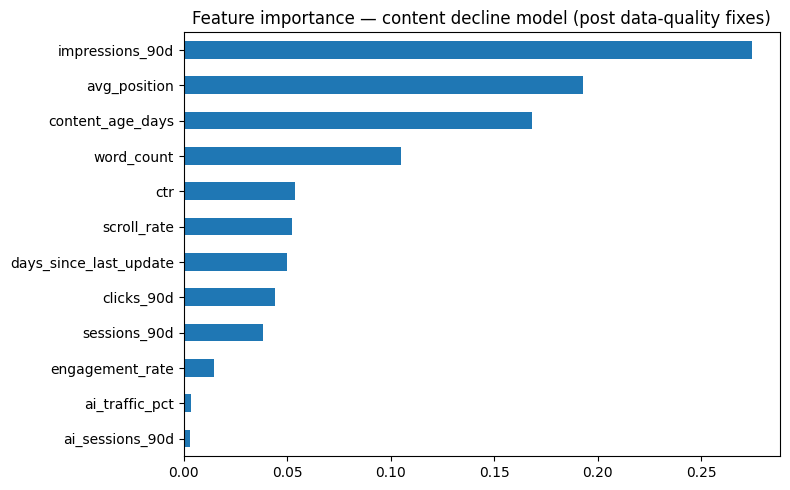

Exported: work/outputs/content_action_queue.csv (not committed, regenerated on run)
Exported: work/outputs/playbook_metrics.json (commit this)
Exported: work/figures/feature_importance.png (commit this)


In [9]:
import os, json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue.to_csv("work/outputs/content_action_queue.csv", index=False)

metrics = {
    "honest_auc_client_grouped": 0.604,
    "naive_auc_ungrouped_DO_NOT_QUOTE": 0.745,
    "auc_without_impressions_90d": 0.551,
    "baseline_rule_flags_total": 10,
    "baseline_rule_flags_total_rows": 30000,
    "queue_total_rows": len(queue),
    "queue_reason_code_counts": queue['reason_code'].value_counts().to_dict(),
    "bulk_event_clients_count": len(suspect_clients),
    "bulk_event_rows_pct": round(df['bulk_event_flag'].mean() * 100, 1),
    "decline_rate_bulk_event_true": 0.563,
    "decline_rate_bulk_event_false": 0.516,
    "ctr_unit_bug_rows_fixed": 1689,
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

importances = model.feature_importances_
fig, ax = plt.subplots(figsize=(8, 5))
pd.Series(importances, index=feature_cols).sort_values().plot.barh(ax=ax)
ax.set_title("Feature importance — content decline model (post data-quality fixes)")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()

print("Exported: work/outputs/content_action_queue.csv (not committed, regenerated on run)")
print("Exported: work/outputs/playbook_metrics.json (commit this)")
print("Exported: work/figures/feature_importance.png (commit this)")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.